In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

## 1. A dataset that is NOT linearly separable

make_moons is a classic synthetic dataset: two classes that draw interlocking half-moons. *No straight line* can separate them correctly. No matter how we tune the weights, a linear boundary will misclassify points along the curve.


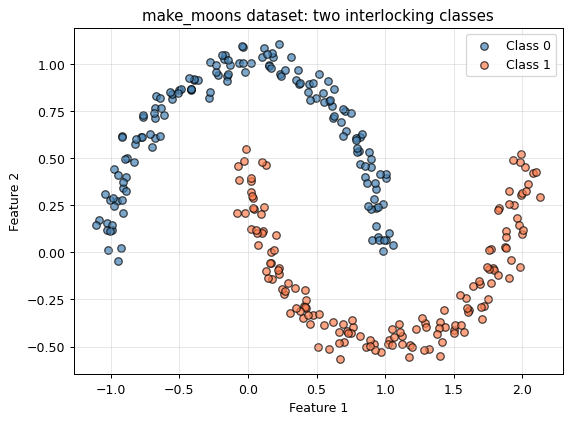

In [6]:
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', label='Class 1', alpha=0.7, edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('make_moons dataset: two interlocking classes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Mejores hiperparámetros encontrados: {'max_depth': 6, 'min_samples_leaf': 5}
Decision Tree accuracy (test): 0.850


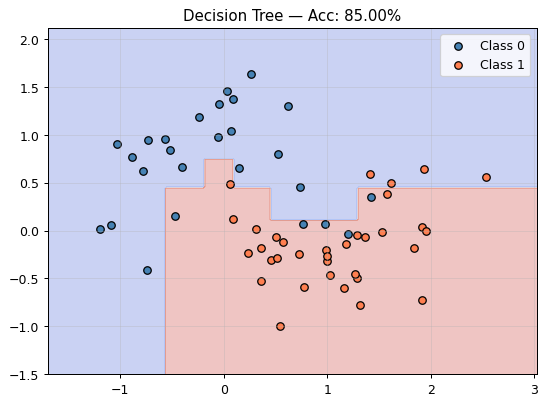

In [5]:
def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# 1. Instanciamos el Árbol de Decisión
tree = DecisionTreeClassifier(random_state=42)

# 2. Definimos una grilla de hiperparámetros para evitar el sobreajuste (overfitting)
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_leaf': [1, 5, 10, 15]
}

# 3. Usamos GridSearchCV para encontrar la mejor combinación
grid_search = GridSearchCV(tree, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 4. Extraemos el mejor modelo
best_tree = grid_search.best_estimator_

# 5. Evaluamos el accuracy con los datos de prueba
acc_tree = accuracy_score(y_test, best_tree.predict(X_test))

print(f'Mejores hiperparámetros encontrados: {grid_search.best_params_}')
print(f'Decision Tree accuracy (test): {acc_tree:.3f}')

# 6. Graficamos la nueva frontera de decisión
plot_decision_boundary(best_tree, X_test, y_test, f'Decision Tree — Acc: {acc_tree:.2%}')

## 3. Attempt 2: decision tree

A tree works in a radically different way. Instead of learning weights, it *learns questions*:


Is Feature 2 > 0.3?
├── Yes → Is Feature 1 > 0.5?
│   ├── Yes → Class 1
│   └── No  → Class 0
└── No  → Is Feature 1 > -0.2?
    ├── Yes → Class 0
    └── No  → Class 1


Each question splits the space with a *line parallel to one axis*. The combination of several questions produces a staircase-shaped boundary that can approximate any shape.

Decision tree accuracy (max_depth=5, test): 0.950
Improvement over logistic regression: +6.7 points


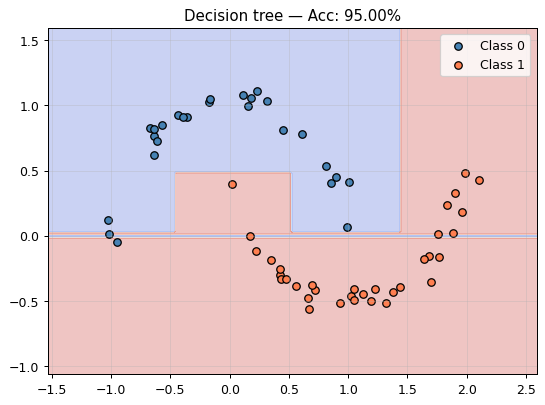

In [ ]:
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree.predict(X_test))

print(f'Decision tree accuracy (max_depth=5, test): {acc_tree:.3f}')
print(f'Improvement over logistic regression: +{(acc_tree - acc_logreg)*100:.1f} points')

plot_decision_boundary(tree, X_test, y_test, f'Decision tree — Acc: {acc_tree:.2%}')

Mejores parámetros encontrados: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Optimized Decision tree accuracy (test): 0.983
Improvement over logistic regression: +10.0 points


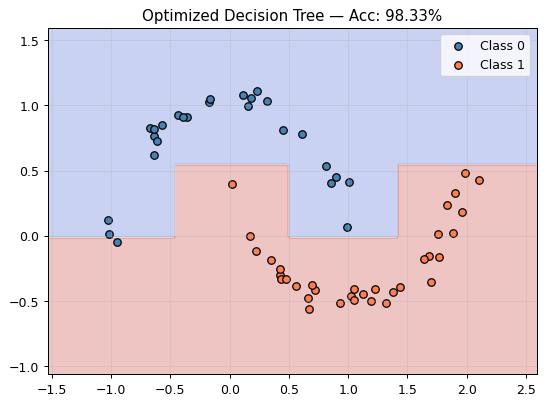

In [8]:
from sklearn.model_selection import GridSearchCV

# 1. Definimos el espacio de búsqueda de hiperparámetros
param_grid = {
    'criterion': ['gini', 'entropy'],       # Diferentes formas de medir la pureza del corte
    'max_depth': [3, 4, 5, 6, 7, 8, None],  # Probamos distintas profundidades
    'min_samples_leaf': [1, 2, 5, 10],      # Mínimo de muestras permitidas al final de una rama
    'min_samples_split': [2, 5, 10]         # Mínimo de muestras para permitir una división
}

# 2. Instanciamos el árbol base
base_tree = DecisionTreeClassifier(random_state=42)

# 3. Configuramos la búsqueda exhaustiva con validación cruzada de 5 particiones (cv=5)
grid_search = GridSearchCV(estimator=base_tree, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 4. Entrenamos para encontrar la combinación perfecta
grid_search.fit(X_train, y_train)

# 5. Extraemos el modelo ganador
best_tree = grid_search.best_estimator_

# 6. Evaluamos el nuevo árbol optimizado
acc_best_tree = accuracy_score(y_test, best_tree.predict(X_test))

print(f'Mejores parámetros encontrados: {grid_search.best_params_}')
print(f'Optimized Decision tree accuracy (test): {acc_best_tree:.3f}')

# Nota: Asumiendo que 'acc_logreg' todavía está en memoria de tu primera ejecución
try:
    print(f'Improvement over logistic regression: +{(acc_best_tree - acc_logreg)*100:.1f} points')
except NameError:
    pass # Si acc_logreg no está definido en esta ejecución, simplemente se omite

# 7. Graficamos la frontera del mejor árbol
plot_decision_boundary(best_tree, X_test, y_test, f'Optimized Decision Tree — Acc: {acc_best_tree:.2%}')

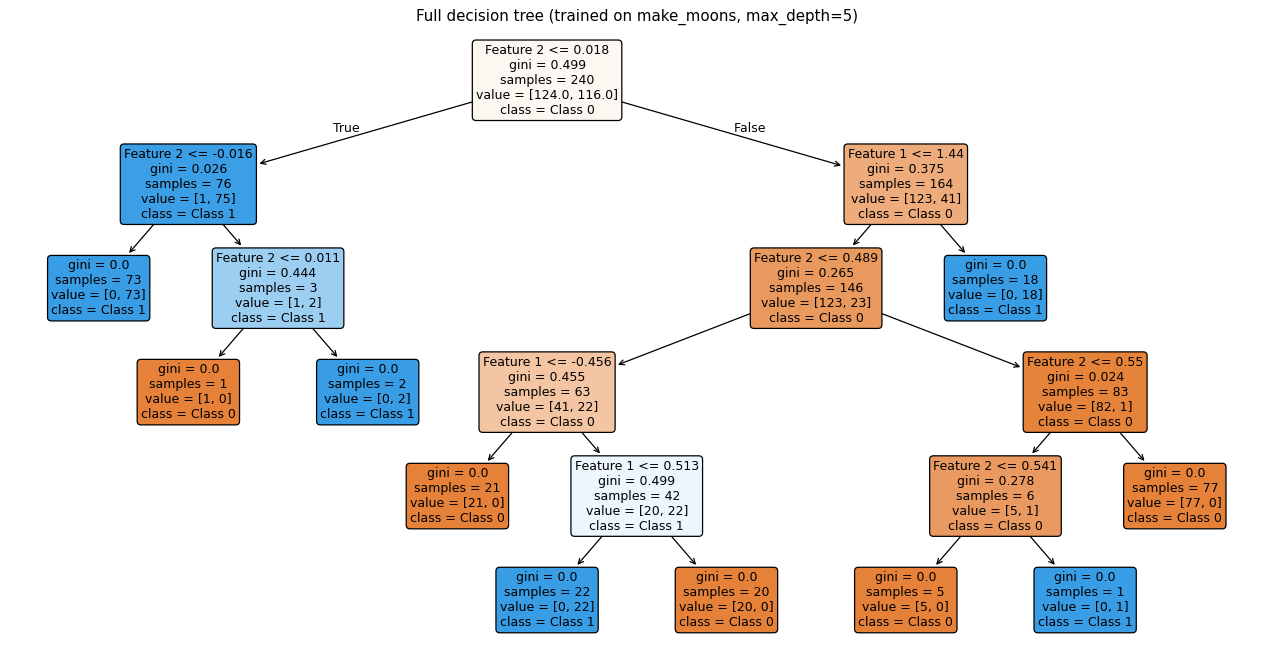

In [10]:
plt.figure(figsize=(18, 9))
plot_tree(
    tree,
    filled=True,
    rounded=True,
    feature_names=['Feature 1', 'Feature 2'],
    class_names=['Class 0', 'Class 1'],
    fontsize=10
)
plt.title('Full decision tree (trained on make_moons, max_depth=5)')
plt.show()

# Explanation of the Decision Tree Visualization

This code block uses the `plot_tree` function from `scikit-learn` in combination with `matplotlib` to generate a visual representation of the decision tree you just trained. 

Since a tree with `max_depth=5` can have up to 32 leaf nodes, this visualization is key to understanding the algorithm's internal logic, meaning, what mathematical decisions it is making at each branch.

Below is the line-by-line breakdown of what each parameter does:

## Canvas Preparation
`plt.figure(figsize=(18, 9))`
* **What it does:** Defines the figure size in inches (18 wide by 9 tall).
* **Why it is important:** A tree with a depth of 5 is quite wide. If you don't increase the `figsize`, the nodes will overlap and the text will be completely unreadable.

## Plot Generation (`plot_tree`)

`plot_tree(tree, ...)`
* **`tree`:** This is your trained model object (an instance of `DecisionTreeClassifier`). It contains the entire structure of mathematical rules calculated during training.

`filled=True,`
* **What it does:** Colors the inside of the rectangles (nodes).
* **Interpretation:** This is one of the most useful parameters. The color represents the majority class, and the **intensity of the color** represents the node's "purity". A very strong color indicates that almost all samples in that node belong to a single class (high purity / low Gini index), while a pale color indicates that the node is undecided (a mix of both classes).

`rounded=True,`
* **What it does:** Simply rounds the corners of the node rectangles for aesthetic purposes.

`feature_names=['Feature 1', 'Feature 2'],`
* **What it does:** Replaces generic NumPy array indices with readable labels on the first line of each node.
* **Result:** Instead of seeing abstract rules like `X[0] <= 0.5`, you will see `Feature 1 <= 0.5`, which makes it easier to interpret the variables.

`class_names=['Class 0', 'Class 1'],`
* **What it does:** Translates the target variable (which in the original code are zeros and ones) into descriptive names.
* **Result:** Each node will show a line at the bottom indicating what classification the model would assign if a prediction ended at that exact point in the tree.

`fontsize=10)`
* **What it does:** Adjusts the font size inside the nodes. If the tree is very dense, it is sometimes necessary to reduce this value to 8 or 6 so the text doesn't overflow the rectangle.

## Finalization and Rendering
`plt.title('Full decision tree (trained on make_moons, max_depth=5)')`  
`plt.show()`
* **What it does:** Adds the top title and forces `matplotlib` to display the window or image in your development environment, clearing the memory buffer.

---

## What will you see inside each node in the final plot?
Thanks to the configuration you applied, each box in the graph will show this information from top to bottom:

1. **The splitting rule:** E.g., `Feature 2 <= 0.245` (Only in decision nodes, not in the final leaves).
2. **The purity criterion:** E.g., `gini = 0.48` or `entropy = ...` indicating the mix of classes.
3. **Samples (`samples`):** E.g., `samples = 150`, the number of training data points that passed through that node.
4. **Values (`value`):** E.g., `value = [100, 50]`, how those samples are distributed among the different classes.
5. **Majority class (`class`):** E.g., `class = Class 0`, the final prediction of that node.

## Datos apropiados para los bosques de decisión
Los bosques de decisión son más efectivos cuando se tiene un conjunto de datos tabular (datos que podrías representar en una hoja de cálculo, archivo CSV o tabla de base de datos). 

Los datos tabulares son uno de los formatos más comunes, y los bosques de decisión deberían ser tu solución predeterminada para modelarlos.

**Ejemplo de tabla (Estadísticas de Jugadores Mundial 2026):**

| Goles Anotados | Atajadas | Valor de Mercado (Millones €) | Posición (Etiqueta/Label) |
| :--- | :--- | :--- | :--- |
| 8 | 0 | 180.0 | Delantero |
| 0 | 15 | 35.0 | Portero |
| 2 | 0 | 85.0 | Defensa |

A diferencia de las redes neuronales, los bosques de decisión consumen de forma nativa datos tabulares. Al desarrollarlos, **no tienes que hacer tareas como las siguientes**:
* Realizar preprocesamientos como normalización de características (feature normalization) o codificación one-hot.
* Realizar imputación (por ejemplo, reemplazar un valor faltante con -1).

Sin embargo, **no son muy adecuados para consumir directamente datos no tabulares** (datos no estructurados), como imágenes del partido o texto (comentarios de los narradores).

*Nota:* Los bosques de decisión son **eficientes con las muestras (sample efficient)**. Son ideales para conjuntos de datos pequeños, aunque, como todo modelo de ML, funcionan mejor cuando hay muchos datos disponibles. Además, la inferencia suele ser de microsegundos en un CPU moderno.

## Árboles de Decisión (Decision Trees)
Los modelos de bosques de decisión están compuestos por árboles de decisión. Un árbol de decisión es un modelo compuesto por una colección de "preguntas" organizadas jerárquicamente en forma de árbol.

* Las preguntas suelen llamarse **condición (condition)**, **división (split)** o **prueba (test)**.
* Cada **nodo no hoja (non-leaf node)** contiene una condición, y cada **nodo hoja (leaf node)** contiene una predicción.
* Se representan con la **raíz (root)** en la parte superior.

### Estructura de un Árbol de Decisión (Ejemplo Fútbol)
* **Raíz (Root):** `Goles_Anotados >= 5`
    * **Sí (Yes) -> Nodo Hoja (Predicción):** Delantero
    * **No (No) -> Nodo no hoja (Condición):** `Atajadas >= 10`
        * **Sí (Yes) -> Nodo Hoja (Predicción):** Portero
        * **No (No) -> Nodo Hoja (Predicción):** Defensa / Mediocampista

IMAGEN

## Inferencia en Árboles de Decisión
La inferencia se calcula enrutando un ejemplo desde la raíz hasta uno de los nodos hoja según las condiciones. El valor de la hoja alcanzada es la predicción. El conjunto de nodos visitados se llama **ruta de inferencia (inference path)**.

**Ejemplo de inferencia:**
Características del jugador ingresado:
* `Goles_Anotados` = 1
* `Atajadas` = 12

**Ruta:**
1. `Goles_Anotados >= 5` -> **No**
2. `Atajadas >= 10` -> **Sí (Yes)**
* **Predicción:** Portero.

IMAGEN

## Predicciones Regresivas
En el ejemplo anterior, las hojas contienen clasificaciones (Posición en el campo). De forma similar, los árboles de decisión pueden predecir **valores numéricos** etiquetando las hojas con predicciones regresivas.

**Ejemplo:** Predecir el *Valor de Mercado* de un jugador (en Millones de Euros).
* Raíz: `Goles_Anotados >= 10`
    * **Sí ->** `Asistencias >= 5`
        * Sí -> **150.5 M**
        * No -> **90.0 M**
    * **No ->** **45.2 M**

## Tipos de Condiciones: Alineadas a los ejes vs. Oblicuas (Axis-aligned vs. oblique)

1. **Condición alineada a los ejes (Axis-aligned):** Involucra solo una característica.
   * *Ejemplo:* `Goles_Anotados >= 5`
   
2. **Condición oblicua (Oblique):** Involucra múltiples características al mismo tiempo. Las divisiones oblicuas son más poderosas porque expresan patrones más complejos, aunque aumentan los costos de entrenamiento.
   * *Ejemplo (Índice de Contribución Ofensiva):* `Goles_Anotados + (Asistencias * 2) >= 15`

## Tipos de Condiciones: Binarias vs. No Binarias

* **Condiciones Binarias:** Tienen dos resultados posibles (Verdadero o Falso). Los árboles que solo contienen estas condiciones son *árboles de decisión binarios*. (Ej. `Goles >= 5` -> Sí/No).
* **Condiciones No Binarias:** Tienen más de dos resultados posibles. Tienen más poder de discriminación, pero es más probable que sufran de sobreajuste (overfit). (Ej. `Posición` -> Delantero, Medio, Defensa, Portero).

*Nota:* Los bosques de decisión generalmente usan árboles binarios, ya que una condición no binaria se puede emular con múltiples condiciones binarias.

### Tabla Resumen de Condiciones (Ejemplos del Mundial 2026)

| Nombre (Name) | Formato (Condition) | Ejemplo (Example) |
| :--- | :--- | :--- |
| **Condición de umbral** *(threshold condition)* | `feature > threshold` | `Goles_Anotados >= 5` |
| **Condición de igualdad** *(equality condition)* | `feature = value` | `Seleccion = "Ecuador"` |
| **Condición de pertenencia** *(in-set condition)* | `feature ∈ collection` | `Seleccion ∈ {"Ecuador", "Argentina", "Brasil"}` |
| **Condición oblicua** *(oblique condition)* | `Σ (weight * feature) ≥ threshold` | `Goles + (2 * Asistencias) >= 15` |
| **Característica faltante** *(feature is missing)*| `feature isMissing` | `Minutos_Jugados isMissing` |